Using device: cuda


100%|██████████| 45/45 [02:53<00:00,  3.85s/it]


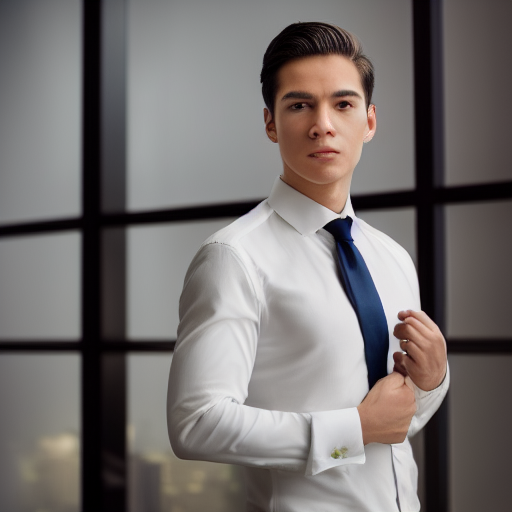

In [ ]:
import model_loader
import pipeline
from PIL import Image
from pathlib import Path
from transformers import CLIPTokenizer
import torch

DEVICE = "cpu"

ALLOW_CUDA = True
ALLOW_MPS = True

if torch.cuda.is_available() and ALLOW_CUDA:
    DEVICE = "cuda"
elif (torch.has_mps or torch.backends.mps.is_available()) and ALLOW_MPS:
    DEVICE = "mps"
print(f"Using device: {DEVICE}")

tokenizer = CLIPTokenizer("../data/vocab.json", merges_file="../data/merges.txt")
model_file = "../data/v1-5-pruned-emaonly.ckpt"
models = model_loader.preload_models_from_standard_weights(model_file, DEVICE)

## TEXT TO IMAGE

prompt = "A professional studio portrait of a confident business executive, sharp focus, ultra-detailed skin texture, soft studio lighting with rim light, shallow depth of field, bokeh background, wearing a tailored navy suit with a crisp white shirt, natural skin tones, catch light in eyes, shot on Canon EOS R5 with 85mm f/1.4 lens, 8k resolution, award-winning photography, editorial style, color graded, cinematic lighting, golden hour ambient fill, professional retouching"
# prompt = "A cat stretching on the floor, highly detailed, ultra sharp, cinematic, 100mm lens, 8k resolution."
uncond_prompt = "blurry, low quality, deformed, disfigured, bad anatomy, extra limbs, mutated hands, poorly drawn face, watermark, text, logo, oversaturated, cartoon, anime, illustration, painting, cropped, out of frame, duplicate, ugly, morbid, grainy, low resolution, bad proportions, extra fingers"  # Also known as negative prompt
# uncond_prompt = ""
do_cfg = True
cfg_scale = 8  # min: 1, max: 14


input_image = None
# Comment to disable image to image
# image_path = r"N:\AI\stable-diffusion\images\dog.jpeg"
# input_image = Image.open(image_path)
strength = 0.9

sampler = "ddpm"
num_inference_steps = 50
seed = 42

output_image = pipeline.generate(
    prompt=prompt,
    uncond_prompt=uncond_prompt,
    input_image=input_image,
    strength=strength,
    do_cfg=do_cfg,
    cfg_scale=cfg_scale,
    sampler_name=sampler,
    n_inference_steps=num_inference_steps,
    seed=seed,
    models=models,
    device=DEVICE,
    idle_device="cpu",
    tokenizer=tokenizer,
)

Image.fromarray(output_image)